# Learning-to-Rank: Did It Actually Improve Search?

The lexical baseline is already strong: TF-IDF reaches **0.8173 NDCG@10** on the frozen project-validation split.

This notebook asks a narrower question:

> **Can a query-grouped XGBRanker combine lexical and structured signals well enough to beat TF-IDF?**

The answer is **yes, modestly**. The more interesting part is *why*.

This notebook reads saved artifacts only. It does **not** retrain the primary model, and the official ESCI test holdout remains untouched.


In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
METRICS = ROOT / "artifacts" / "metrics"
EXAMPLES = ROOT / "artifacts" / "examples"

summary = json.loads((METRICS / "ranker_summary.json").read_text())
vs_tfidf = json.loads((METRICS / "ranker_vs_tfidf.json").read_text())

importance = pd.read_csv(METRICS / "ranker_feature_importance.csv")
ablation = pd.read_csv(METRICS / "ranker_ablation.csv")
segments = pd.read_csv(METRICS / "ranker_segments.csv")
per_query = pd.read_csv(METRICS / "ranker_per_query.csv")
examples = pd.read_csv(EXAMPLES / "ranker_query_examples.csv")

print(f"Partition: {summary['partition']}")
print(f"Validation queries: {summary['queries']:,}")
print("Primary model retrained here: NO")
print("Official test used: NO")


Partition: project_validation
Validation queries: 3,134
Primary model retrained here: NO
Official test used: NO


## 1. Did learning-to-rank help?

The comparison is fair: Random, BM25, TF-IDF, and XGBRanker all use the **same project metric implementation** on the same **3,134 validation queries**.


In [2]:
rows = []

for name in ("random", "bm25", "tfidf"):
    rows.append(
        {
            "Model": "TF-IDF" if name == "tfidf" else name.upper(),
            **summary["baseline_references"][name],
        }
    )

rows.append({"Model": "XGBRanker", **summary["XGBRanker"]})

results = pd.DataFrame(rows)[
    ["Model", "ndcg@10", "recall@10", "mrr"]
]

display(results.round(4))

print(f"Mean ΔNDCG@10 vs TF-IDF:   {vs_tfidf['mean_delta']:+.6f}")
print(f"Median ΔNDCG@10:           {vs_tfidf['median_delta']:+.6f}")
print(
    f"Wins / losses / ties:      "
    f"{vs_tfidf['wins']} / {vs_tfidf['losses']} / {vs_tfidf['ties']}"
)
print(
    "Bootstrap 95% CI:          "
    f"[{vs_tfidf['bootstrap_ci_95'][0]:.6f}, "
    f"{vs_tfidf['bootstrap_ci_95'][1]:.6f}]"
)


,Model,ndcg@10,recall@10,mrr
0,RANDOM,0.7611,0.5684,0.8757
1,BM25,0.8124,0.5906,0.8988
2,TF-IDF,0.8173,0.5922,0.9060
3,XGBRanker,0.8236,0.5929,0.9089


Mean ΔNDCG@10 vs TF-IDF:   +0.006329
Median ΔNDCG@10:           +0.000854
Wins / losses / ties:      1580 / 1226 / 328
Bootstrap 95% CI:          [0.003667, 0.009108]


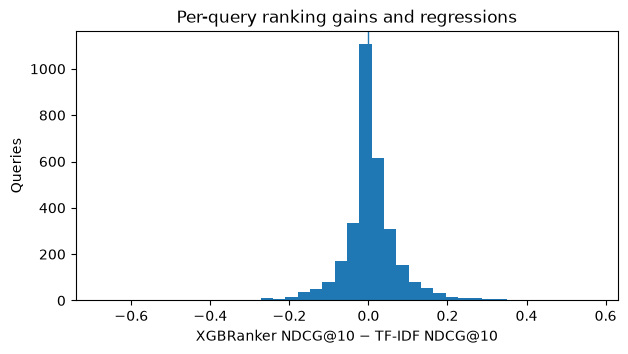

In [3]:
plt.figure(figsize=(7, 3.5))
plt.hist(per_query["delta_ndcg_at_10"], bins=40)
plt.axvline(0, linewidth=1)
plt.xlabel("XGBRanker NDCG@10 − TF-IDF NDCG@10")
plt.ylabel("Queries")
plt.title("Per-query ranking gains and regressions")
plt.show()


**Takeaway.** XGBRanker improves mean NDCG@10 from **0.8173 to 0.8236**. The gain is small, but the bootstrap interval is entirely above zero.

The model still loses on many queries, so the useful question is not just *whether* it improved ranking—it is **what information created the improvement and where the model fails**.


## 2. What signals mattered?

The ranker uses 10 features:

- **Lexical scores:** BM25, TF-IDF
- **Overlap / coverage:** shared tokens, query coverage, title coverage, exact phrase, bullet coverage
- **Structured / length:** brand match, title length, query-title length difference

Feature importance tells us what the fitted trees used. Ablation tells us what was actually difficult to remove.


,rank,feature,gain_importance
0,1,tfidf_score,0.3363
1,2,query_token_coverage,0.2157
2,3,title_token_coverage,0.1114
3,4,query_bullet_coverage,0.0784
4,5,brand_match,0.0514
5,6,exact_query_in_title,0.0499
6,7,title_token_count,0.0458
7,8,token_length_difference,0.0394
8,9,shared_token_count,0.0359
9,10,bm25_score,0.0358


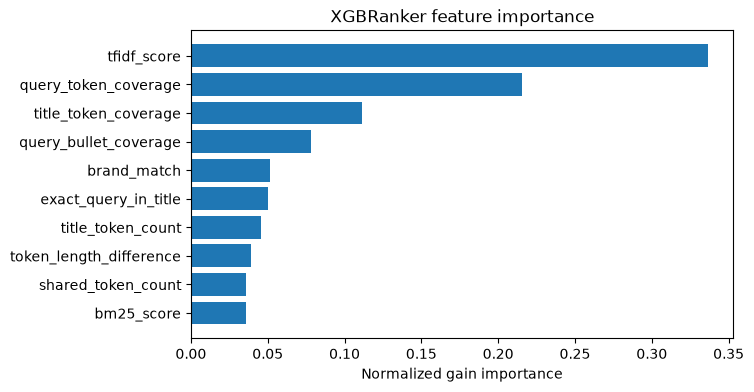

In [4]:
display(
    importance[
        ["rank", "feature", "gain_importance"]
    ].round({"gain_importance": 4})
)

plot = importance.sort_values("gain_importance")

plt.figure(figsize=(7, 4))
plt.barh(plot["feature"], plot["gain_importance"])
plt.xlabel("Normalized gain importance")
plt.title("XGBRanker feature importance")
plt.show()


In [5]:
ablation_view = ablation[
    [
        "variant",
        "n_features",
        "ndcg@10",
        "delta_vs_full",
        "delta_vs_tfidf",
    ]
].copy()

display(ablation_view.round(6))


,variant,n_features,ndcg@10,delta_vs_full,delta_vs_tfidf
0,full,10,0.823622,0.000000,0.006329
1,lexical_scores,2,0.815728,-0.007894,-0.001564
2,minus_tfidf,9,0.823376,-0.000246,0.006083
3,minus_bm25,9,0.823781,0.000159,0.006488
4,minus_overlap,5,0.821276,-0.002346,0.003983
5,minus_structured,7,0.822530,-0.001093,0.005237


### What the ablation tells us

Three findings matter:

1. **BM25 + TF-IDF alone is not enough.**  
   The lexical-score-only ranker falls slightly below raw TF-IDF.

2. **Overlap / coverage features create real incremental value.**  
   Removing them causes the largest meaningful drop from the full model.

3. **Feature importance is not the same as unique value.**  
   TF-IDF has the highest gain importance, but removing it barely changes NDCG because several overlap features encode related lexical information.

BM25 contributes little once the other signals are present. That is useful diagnostic evidence, but the approved full model stays frozen rather than being changed post hoc.


## 3. Where does the model win—and where does it fail?

A few representative queries make the model behavior much easier to understand than another aggregate metric.


In [6]:
PREVIEW_COLS = [
    "xgb_rank",
    "tfidf_rank",
    "esci_label",
    "product_title",
    "tfidf_score",
    "bm25_score",
]

def show_query(query_id, n=6):
    block = examples.loc[
        examples["query_id"] == query_id
    ].sort_values("xgb_rank")

    query = block["query"].iloc[0]
    delta = block["delta_ndcg_at_10"].iloc[0]

    print(
        f"query_id={query_id} | "
        f"{query} | "
        f"ΔNDCG@10={delta:+.4f}"
    )
    display(block[PREVIEW_COLS].head(n))


query_deltas = (
    examples[["query_id", "delta_ndcg_at_10"]]
    .drop_duplicates()
)

best_queries = (
    query_deltas
    .nlargest(2, "delta_ndcg_at_10")["query_id"]
    .tolist()
)

worst_queries = (
    query_deltas
    .nsmallest(2, "delta_ndcg_at_10")["query_id"]
    .tolist()
)

for query_id in best_queries + worst_queries:
    show_query(query_id)


query_id=100955 | tea bag dish alice | ΔNDCG@10=+0.5693


,xgb_rank,tfidf_rank,esci_label,product_title,tfidf_score,bm25_score
72,1,4,E,Disney Parks Exclusive Alice in Wonderland Tea...,0.169476,1.246647
73,2,1,I,10pcs Silicone Tea Bag Holders Multi-color Sna...,0.299696,2.335592
74,3,3,I,Alice in Wonderland 3x Mini Tea Tin Gift Pack ...,0.192609,1.274791
75,4,5,I,Alice In Wonderland Tea Tin with 40 English Af...,0.157048,1.203915
76,5,2,I,24 Pieces Cute Snail Shape Silicone Tea Bag Ho...,0.241333,2.065358
77,6,6,I,Live Nice Alices Adventures - Alice Wonderland...,0.143754,1.126676


query_id=107914 | vape without nicotine | ΔNDCG@10=+0.5197


,xgb_rank,tfidf_rank,esci_label,product_title,tfidf_score,bm25_score
104,1,13,E,One Step at a Time Nicotine Addiction Withdraw...,0.047237,0.933664
105,2,6,S,Menthol - Herbal Cigarettes - Tobacco and Nico...,0.083810,0.994788
106,3,20,E,Quit Smoking Aid Oxygen Inhaler + Soft Tip Che...,0.037962,0.625969
107,4,1,C,Skin Decal Vinyl Wrap for Smok Stick V8 Pen Va...,0.220572,2.988088
108,5,23,E,"Stop Smoking Remedy, Smoke-Free Oxygen Inhaler...",0.037167,0.601203
109,6,8,S,Herbal Cigarettes - Tobacco and Nicotine Free ...,0.062116,0.905835


query_id=67057 | melissa moore | ΔNDCG@10=-0.6783


,xgb_rank,tfidf_rank,esci_label,product_title,tfidf_score,bm25_score
40,1,13,I,RiffTrax Live: Samurai Cop,0.0,0.0
41,2,14,I,C.I.A. Code Name: Alexa,0.0,0.0
42,3,16,I,Shock Cinema Volume 2,0.0,0.0
43,4,12,I,Revenge Of The Samurai Cop,0.0,0.0
44,5,3,I,Miss March UNRATED,0.0,0.0
45,6,9,I,The Killing Zone,0.0,0.0


query_id=78865 | pentrrex 4oz | ΔNDCG@10=-0.6560


,xgb_rank,tfidf_rank,esci_label,product_title,tfidf_score,bm25_score
56,1,5,I,JointFlex Pain Relief Cream for Joint & Arthri...,0.0,0.0
57,2,10,I,"Heel Traumeel S Cream Tube - Pain Relief, 50 G...",0.0,0.0
58,3,13,I,ArnitRX Pain Relief Cream 4 oz Jar! Anti-infla...,0.0,0.0
59,4,9,I,Plantar Fasciitis Foot Pain Relief Cream Fast ...,0.0,0.0
60,5,15,I,"Hemp Cream 3,000,000 Super Efficiency - Natura...",0.0,0.0
61,6,14,I,SaltWrap Joint Clinic - Joint Recovery Multivi...,0.0,0.0


### Pattern behind the examples

**Where LTR helps**
- TF-IDF overweights a rare matching token but misses the actual product type.
- Explicit query/title coverage helps distinguish a superficially similar product from a better overall match.

**Where LTR hurts**
- Coverage can reward generic overlapping words even when a distinctive intent-bearing word matters more.
- The current features do not understand **negation**.
- Typos and zero-overlap queries leave the model with weak lexical evidence.

Those failures point naturally toward the next modeling question: **semantic relevance**.


## 4. Does query length change the result?

This is only a lightweight diagnostic—not the full search-quality segmentation framework planned later.


In [7]:
display(segments.round(6))


,query_length_segment,n_queries,mean_delta_ndcg_at_10
0,1 token,100,0.019163
1,2–3 tokens,1377,0.006332
2,4+ tokens,1657,0.005552


## 5. What the analysis established

### Supported conclusions

- A query-grouped XGBRanker **outperforms TF-IDF on project validation**.
- The improvement is small but consistently positive at the query level.
- The gain does **not** come from simply learning a combination of BM25 and TF-IDF.
- Explicit overlap and coverage features provide useful incremental ranking information.
- The model still struggles with negation, typos, and cases where lexical coverage rewards the wrong intent.

### Limitations

- This is still **candidate re-ranking**, not full-catalog retrieval.
- Features are lexical and structured; there are no semantic embeddings yet.
- Results are from the frozen project-validation split only.
- The official ESCI test holdout remains untouched.
- This is not a production or personalized ranking system.

### Next question

> **Does semantic relevance add incremental value beyond the lexical learning-to-rank model?**
